# Задание
• На основе датасета, который был использован вами для промежуточной аттестации (или другого):

• Выберите вещественную переменную в качестве таргета и несколько объясняющих переменных

• Постройте точечные диаграммы (scatterplots) для таргета и каждой фичи, опишите форму взаимосвязи между переменными

• Разделите датасет на обучающую и тестовую выборки

• Сделайте масштабирование объясняющих переменных

• Обучите модели Lasso и Ridge на разных наборах переменных и для разных спецификаций модели на обучающейвыборке

• Сделайте предсказания целевой переменной для тестовой выборки

• Рассчитайте метрики качества

• Выберите спецификацию модели с наилучшим качеством

• Сделайте выводы относительно полученной модели и ее качества

• Разместите блокнот в GitHub и прикрепите ссылку на блокнот в удаленном репозитории


# Подготовка


## Данные

Данные были сформированы из MSSQL Server базы компании и выгружены в Excel для дальнейшей обработки. В качестве источника представлены два набора данных:
* empl_1.xlsx - список сотрудников по месячно, (date - месяц и год, qnt - количество сотрудников, имеющих доступ к компьютерам, qnt_total - общее количество сотрудников)
* data_1.xlsx - список покупок (я удалил конкретные наименования товаров, оставил только категории( date - месяц и год, category - категория, qnt - количество)

## Описание задачи

В качестве задачи я решил взять предсказание затрат на Мониторы в следующем месяце (взял только одну категорию товаров, для примера).


## Импорт пакетов

In [586]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Загрузка данных

In [587]:
employeeRaw = (pd
                .read_excel("empl_1.xlsx")
                .sort_values('date')
)
dataRaw = (pd
           .read_excel("data_1.xlsx")
           .sort_values('date')
)
print("Сотрудники: ", employeeRaw.shape)
print("Покупки: ", dataRaw.shape)

print(dataRaw.groupby("category").nunique().index.tolist())

Сотрудники:  (129, 3)
Покупки:  (4728, 4)
['Батарейка', 'Блок питания', 'Веб-камера', 'Видеокарта', 'Жесткий диск', 'Запчасти для компьютера', 'Запчасти для принтера', 'Кабель/Адаптер', 'Картридж', 'Клавиатура', 'Коммутатор/Свитч/Роутер', 'Компьютер/Ноутбук', 'Корпус компьютерный', 'МФУ', 'Материнская плата', 'Монитор', 'Мышь', 'Наушники', 'ОЗУ', 'Принтер', 'Программное обеспечение', 'Процессор', 'Прочее', 'Сетевое оборудование', 'Смартфон/Мобильное устройство', 'Телевизор', 'Тонер/Чернила', 'Флеш накопитель']


In [588]:
dataRaw.groupby("category").agg(recCount = ("date", "count")).sort_values("recCount", ascending = False)

,recCount
category,
Запчасти для принтера,982
Картридж,801
Прочее,603
Тонер/Чернила,330
Кабель/Адаптер,303
Жесткий диск,222
Мышь,172
Запчасти для компьютера,158
Компьютер/Ноутбук,143


## Подготавливаем данные

In [589]:
## Сотрудники
employee = (
    employeeRaw
    .assign(delta = lambda x: x["qty"] - x["qty"].shift(1))
    .assign(year = lambda x: x["date"].dt.year)
    .assign(month = lambda x: x["date"].dt.month)
    .assign(quarter = lambda x: x["date"].dt.quarter)
    .fillna(0)
)

print(employee)

          date  total_qty  qty  delta  year  month  quarter
0   2016-01-01        842  484    0.0  2016      1        1
1   2016-02-01        840  483   -1.0  2016      2        1
2   2016-03-01        841  487    4.0  2016      3        1
3   2016-04-01        841  489    2.0  2016      4        2
4   2016-05-01        838  489    0.0  2016      5        2
..         ...        ...  ...    ...   ...    ...      ...
124 2026-05-01        997  577    5.0  2026      5        2
125 2026-06-01        997  576   -1.0  2026      6        2
126 2026-07-01        998  578    2.0  2026      7        3
127 2026-08-01        996  577   -1.0  2026      8        3
128 2026-09-01        996  577    0.0  2026      9        3

[129 rows x 7 columns]


In [590]:
## Покупки
dataMonitor = (
    dataRaw[dataRaw["category"] == "Монитор"]
    #dataRaw[dataRaw["category"] == "Запчасти для принтера"] # Самая большая выборка
    #dataRaw[dataRaw["category"] == "Картридж"]
    #dataRaw[dataRaw["category"] == "Компьютер/Ноутбук"]
    .groupby("date")
    .agg(
        data_qty = ("qty", "sum"),
        sum = ("sum", "sum")
    )
    .merge(employee, how="right", on="date")
    # заполняем пропуски методом средней интерполяции
    .interpolate(method='linear')
    .assign(
        is_crysis = lambda x: x["year"] > 2022,
        is_winter = lambda x: x["month"].isin([1, 2, 12]),
        is_spring = lambda x: x["month"].isin([3, 4, 5]),
        is_summer = lambda x: x["month"].isin([6, 7, 8])
    )
    .assign(
        # количество за прошлый месяц
        qty_lag1 = lambda x: x["qty"].shift(1),
        # сумма за прошлый месяц
        sum_lag1 = lambda x: x["sum"].shift(1),
        # количество за прошлый месяц
        sum_avg3 = lambda x: x["sum"].rolling(window=3, min_periods=1).mean(),
        # сумма за прошлый месяц
        data_qty_lag1 = lambda x: x["data_qty"].shift(1),
        # количество за прошлый месяц
        data_qty_avg3 = lambda x: x["data_qty"].rolling(window=3, min_periods=1).mean(),
    )
    # заполняем пропуски последующие
    .ffill()
    # заполняем пропуски предыдущие
    .bfill()
    # заполняем пустоты
    .fillna(0)
)

print(dataMonitor.head(5))

        date  data_qty      sum  total_qty  qty  delta  year  month  quarter  \
0 2016-01-01       1.0  9016.95        842  484    0.0  2016      1        1   
1 2016-02-01       1.0  9016.95        840  483   -1.0  2016      2        1   
2 2016-03-01       1.0  9016.95        841  487    4.0  2016      3        1   
3 2016-04-01       1.0  9016.95        841  489    2.0  2016      4        2   
4 2016-05-01       1.0  9016.95        838  489    0.0  2016      5        2   

   is_crysis  is_winter  is_spring  is_summer  qty_lag1  sum_lag1  sum_avg3  \
0      False       True      False      False     484.0   9016.95   9016.95   
1      False       True      False      False     484.0   9016.95   9016.95   
2      False      False       True      False     483.0   9016.95   9016.95   
3      False      False       True      False     487.0   9016.95   9016.95   
4      False      False       True      False     489.0   9016.95   9016.95   

   data_qty_lag1  data_qty_avg3  
0         

# Домашнее задание

In [591]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

In [592]:
def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1,2, figsize = (15,3))
    sns.histplot(data = data, x = variable, ax = ax[0])
    sns.boxplot(data = data, x = variable, ax = ax[1])
    ax[0].set_title(f'Гистограмма переменной {variable}')
    ax[1].set_title(f'Ящик с усами переменной {variable}')
    plt.show()

## 1. Подготовка данных

(129, 18)
(122, 7)


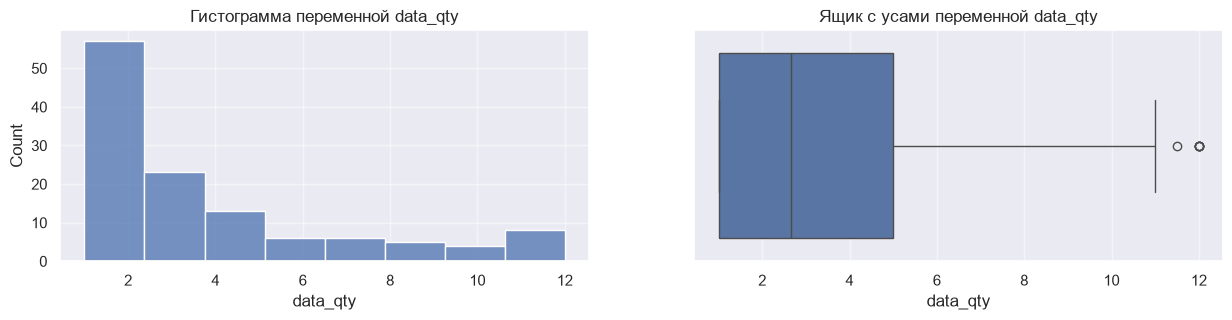

In [593]:
# Убираем выбросы по правилу +/- 2 стандартных отклонения, z-score
numeric_cols = ['data_qty', 'is_winter', 'is_spring', 'is_summer',
'data_qty_lag1', 'qty_lag1', 'data_qty_avg3']
# df = dataMonitor[dataMonitor["is_crysis"] == True]
df = dataMonitor[numeric_cols]
df = df[np.abs((df['data_qty']-df['data_qty'].mean())/df['data_qty'].std())<=2]
print(dataMonitor.shape)
print(df.shape)
visualize_distribution(df, variable = "data_qty")

In [594]:
df.head()

,data_qty,is_winter,is_spring,is_summer,data_qty_lag1,qty_lag1,data_qty_avg3
0,1.0,True,False,False,1.0,484.0,1.0
1,1.0,True,False,False,1.0,484.0,1.0
2,1.0,False,True,False,1.0,483.0,1.0
3,1.0,False,True,False,1.0,487.0,1.0
4,1.0,False,True,False,1.0,489.0,1.0


Sum - Целевая переменная

## 2. Изучаем связь целевой переменной и предикторов

<Figure size 1500x1500 with 0 Axes>

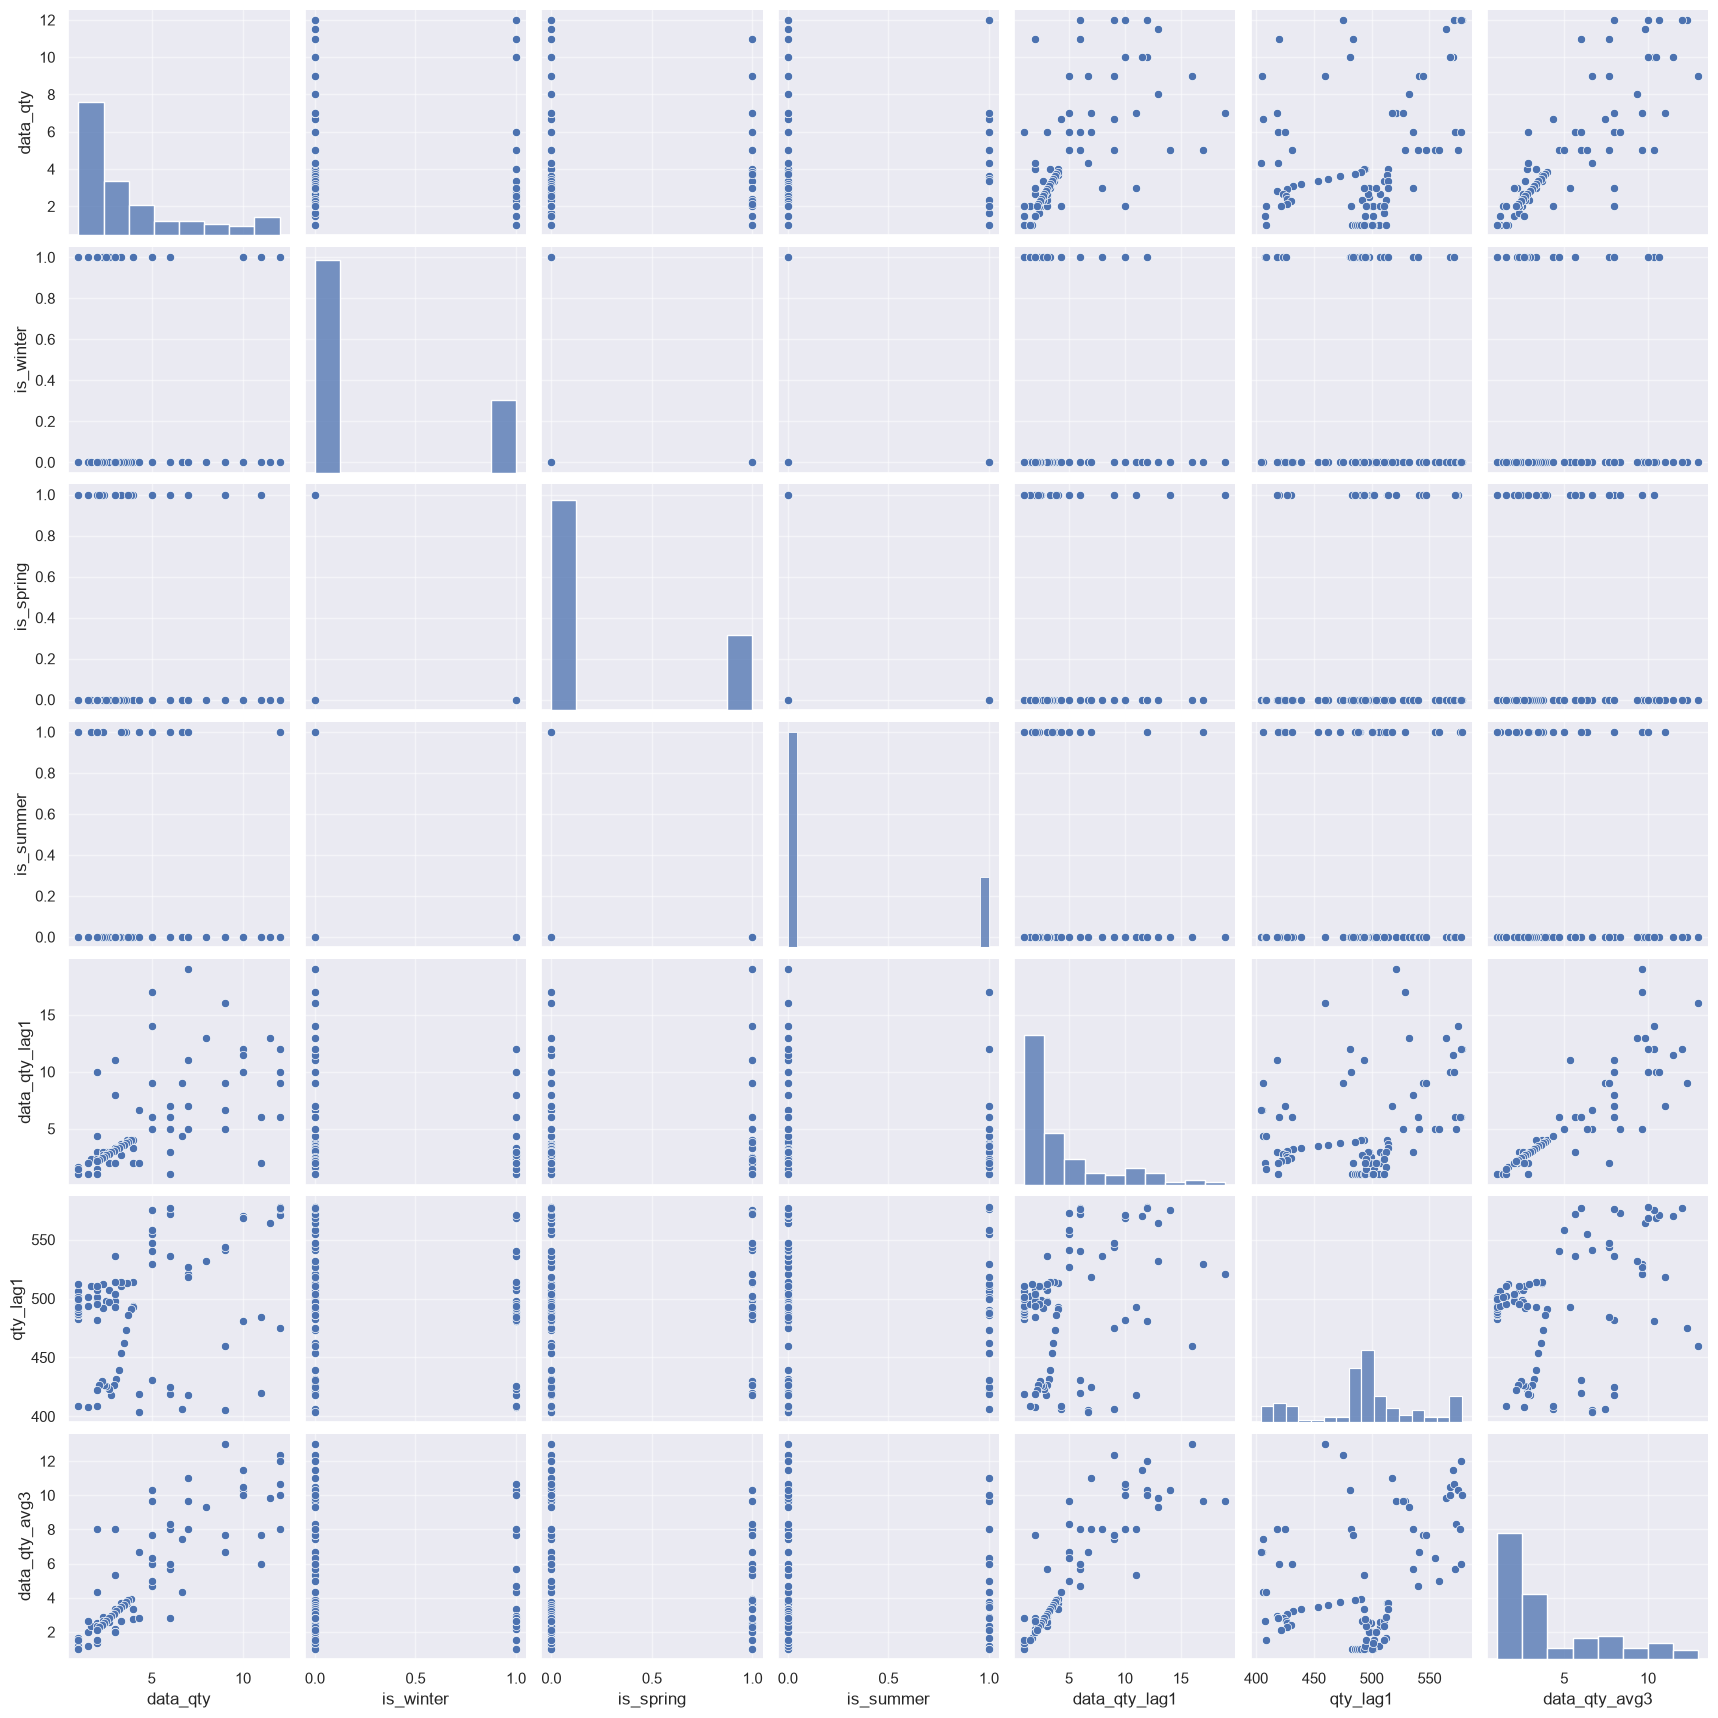

In [595]:
fig = plt.figure(figsize = (15, 15))
sns.pairplot(df)
plt.show()

## 3. Обучим модели линейной регрессии

In [596]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test):
    return model.predict(X_test)

def visualize_prediction(y_true, y_pred):
    fig, ax = plt.subplots(1,1, figsize = (5,5))
    sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
    sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
    ax.set_title("Истинные и предсказанные значения y")
    ax.set_xlabel('true y')
    ax.set_ylabel('pred y')
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Среднеквадратическое отклонение Y: ', np.std(y_test, axis = 0).values[0])
    print('MSE: ', mean_squared_error(y_true, y_pred)),
    print('RMSE: ', root_mean_squared_error(y_true, y_pred))
    print('MAE: ', mean_absolute_error(y_true, y_pred))
    print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
    print('R2: ', r2_score(y_true, y_pred))

def draw_scatteplot(df, x, y, xlab, ylab, y_pred = None):
    data = df.copy()
    plt.figure(figsize = (15,5))
    sns.scatterplot(x = x, y = y, data = data)
    if y_pred is not None:
        data["y_pred"] = y_pred
        sns.lineplot(x = x, y = "y_pred", data = data, c = 'forestgreen')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()

## Variance inflation factor

In [631]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Определим целевую переменную и количественные предикты
target_col = ['data_qty']
features_col = ['is_winter', 'is_spring', 'is_summer', 'data_qty_lag1', 'qty_lag1', 'data_qty_avg3']

X = df[features_col]
y = df[target_col]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data.sort_values(by = 'VIF', ascending = False).reset_index(drop = True)

,feature,VIF
0,data_qty_avg3,5.774504
1,data_qty_lag1,5.638474
2,is_spring,1.599148
3,is_winter,1.570529
4,is_summer,1.567704
5,qty_lag1,1.131918


## Lasso регрессия

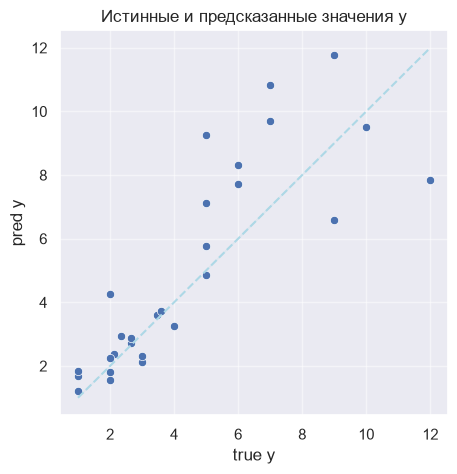

Среднее значение Y:  3.3382113821138213
Среднеквадратическое отклонение Y:  2.8554854828647755
MSE:  2.2984980617905144
RMSE:  1.5160798335808423
MAE:  0.9551982282277585
MAPE:  0.2813556808144686
R2:  0.7181070407881021


In [632]:
# Определим целевую переменную и количественные предикты
target_col = ['data_qty']
# features_col = ['is_winter', 'is_spring', 'is_summer', 'data_qty_lag1', 'qty_lag1', 'data_qty_avg3'] # MSE:  2.31 RMSE:  1.52 MAE:  0.96 MAPE:  0.28 R2:  0.71
# features_col = ['is_winter', 'data_qty_lag1', 'data_qty_avg3']                                       # MSE:  2.31 RMSE:  1.52 MAE:  0.96 MAPE:  0.28 R2:  0.71
# features_col = ['data_qty_lag1', 'qty_lag1', 'data_qty_avg3']                                        # MSE:  2.29 RMSE:  1.51 MAE:  0.95 MAPE:  0.28 R2:  0.71
features_col = ['data_qty_lag1', 'data_qty_avg3']                                                      # MSE:  2.29 RMSE:  1.51 MAE:  0.95 MAPE:  0.28 R2:  0.71
# features_col = ['data_qty_lag1', 'qty_lag1']                                                         # MSE:  3.31 RMSE:  1.81 MAE:  1.25 MAPE:  0.59 R2:  0.59
# features_col = ['data_qty_lag1']                                                                     # MSE:  3.37 RMSE:  1.83 MAE:  1.26 MAPE:  0.58 R2:  0.58

# Разобъем на тестовую и обучающую
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)

# Проведем масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Lasso(alpha = 0.1)
model.fit(X_train_scaled, y_train)

y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

In [630]:
pd.DataFrame(
      index = X_train.columns,
      data = model.coef_
).T

,data_qty_lag1,data_qty_avg3
0,-0.516565,3.389341


Данный подход показывает, что можно принебречь свойствами is_winter и qty_lag1

## Ridge регрессия

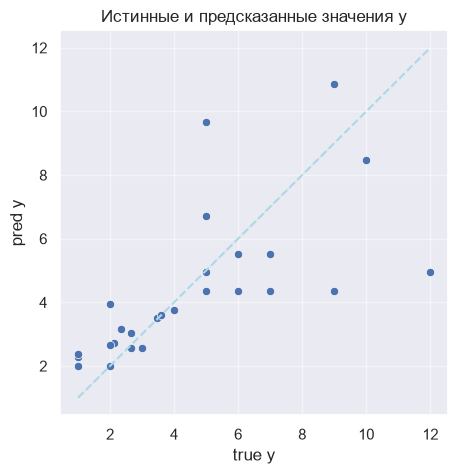

Среднее значение Y:  3.3382113821138213
Среднеквадратическое отклонение Y:  2.8554854828647755
MSE:  3.3531134861208276
RMSE:  1.8311508638342249
MAE:  1.2328071651286925
MAPE:  0.5551938046048911
R2:  0.588766639011388


In [638]:
# Определим целевую переменную и количественные предикты
target_col = ['data_qty']
# features_col = ['is_winter', 'is_spring', 'is_summer', 'data_qty_lag1', 'qty_lag1', 'data_qty_avg3'] # MSE:  3.14 RMSE:  1.77 MAE:  1.10 MAPE:  0.31 R2:  0.61
# features_col = ['is_winter', 'data_qty_lag1', 'data_qty_avg3']                                       # MSE:  3.02 RMSE:  1.73 MAE:  1.09 MAPE:  0.31 R2:  0.62
# features_col = ['data_qty_lag1', 'qty_lag1', 'data_qty_avg3']                                        # MSE:  2.85 RMSE:  1.68 MAE:  0.99 MAPE:  0.24 R2:  0.65
features_col = ['data_qty_lag1', 'data_qty_avg3']                                                      # MSE:  2.80 RMSE:  1.67 MAE:  0.98 MAPE:  0.25 R2:  0.65
# features_col = ['data_qty_lag1', 'qty_lag1']                                                         # MSE:  3.23 RMSE:  1.79 MAE:  1.22 MAPE:  0.56 R2:  0.60
# features_col = ['data_qty_lag1']                                                                     # MSE:  3.35 RMSE:  1.83 MAE:  1.23 MAPE:  0.55 R2:  0.58

# Разобъем на тестовую и обучающую
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)

# Проведем масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge(alpha=0.1)
model.fit(X_train_scaled, y_train)

y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

In [619]:
pd.DataFrame(
      index = X_train.columns,
      data = model.coef_
).T

,is_winter,is_spring,is_summer,data_qty_lag1,qty_lag1,data_qty_avg3
0,-0.162609,0.172013,0.040677,-1.670259,-0.079855,4.570949


## Проверка на устойчивость

In [640]:
metrics_df = pd.DataFrame()
coefs_df = pd.DataFrame()

target_col = ['data_qty']
features_col = ['data_qty_lag1', 'data_qty_avg3']

for random_state in range(0, 20, 2):

  X_train, X_test, y_train, y_test = train_test_split(df[features_col], df[target_col], test_size = 0.33, random_state = random_state)

  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  model = Lasso(alpha = 0.1)
  # model = Ridge(alpha=0.1)
  model.fit(X_train_scaled, y_train)

  y_pred = get_predictions(model, X_test_scaled)

  df1 = pd.DataFrame(
      {
          'MSE'  : mean_squared_error(y_test, y_pred),
          'RMSE' : root_mean_squared_error(y_test, y_pred),
          'MAE'  : mean_absolute_error(y_test, y_pred),
          'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
          'R2'   : r2_score(y_test, y_pred)
      },
      index = [random_state]
  )

  df2 = pd.DataFrame(
      index = X_train.columns,
      data = model.coef_[0],
      columns = [random_state]
  )

  metrics_df = pd.concat([metrics_df, df1])
  coefs_df = pd.concat([coefs_df, df2], axis = 1)
metrics_df

,MSE,RMSE,MAE,MAPE,R2
0,1.722769,1.312543,0.847568,0.262064,0.834328
2,1.290679,1.136081,0.766757,0.291362,0.874035
4,2.567440,1.602323,0.959069,0.309027,0.667379
6,1.881091,1.371529,0.825015,0.319462,0.647406
8,3.909224,1.977176,1.245318,0.353385,0.655842
10,1.785601,1.336264,0.871095,0.281353,0.827802
12,1.110347,1.053730,0.653694,0.259206,0.884361
14,1.444334,1.201804,0.764600,0.268961,0.864263
16,1.785339,1.336166,0.761535,0.178306,0.791673
18,3.934968,1.983675,1.226843,0.308974,0.714619


Из результатов видно, что модель показывает результаты предсказаний по текущим выборкам от 64% до 88%.

Для Ridge показатели будут от 59% до 90 %